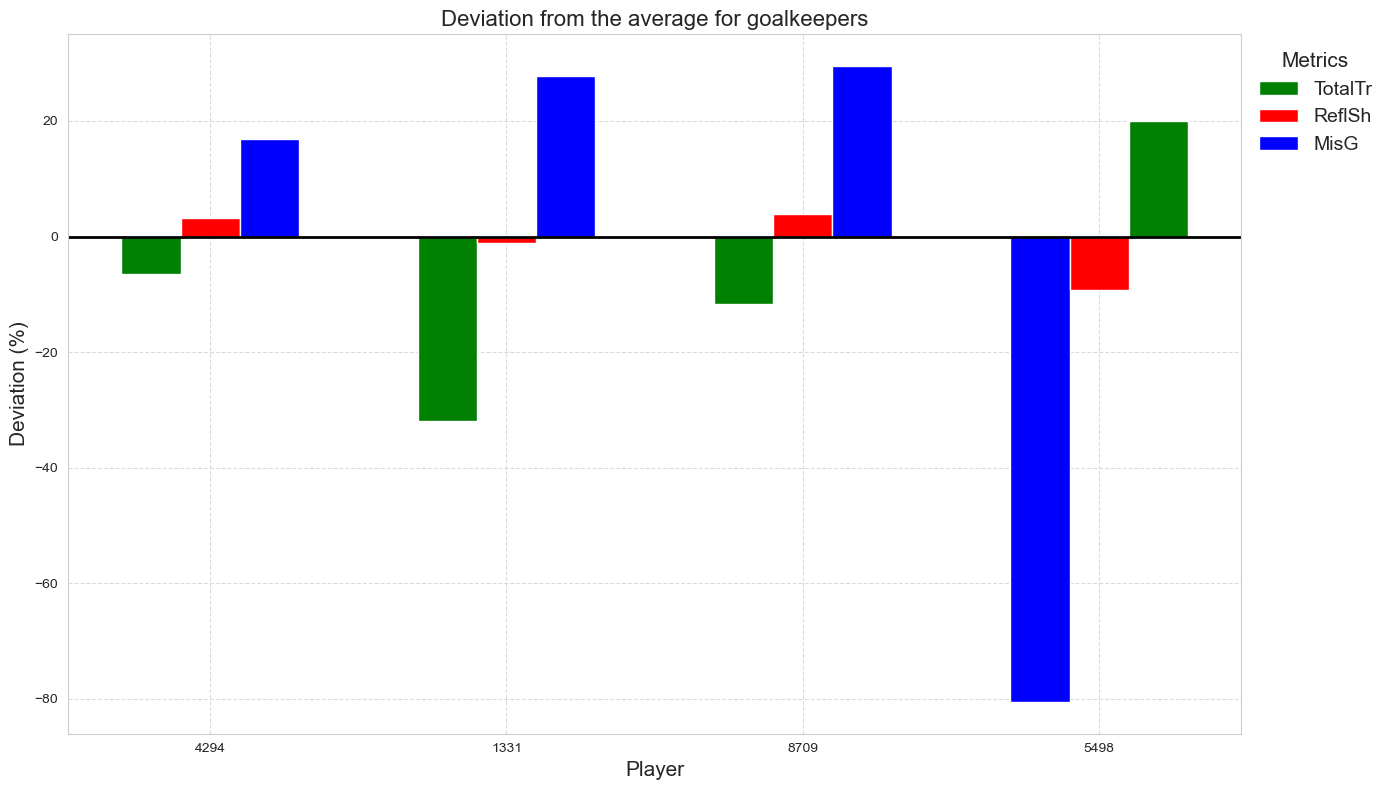

In [5]:
from app.jupiter_notebooks.notebooks.generate_ratings_intg import *

mean_stats_pl = pd.read_csv('data/processed/rating_last_time/mean_stats_pl.csv')
mean_stats_goalk = pd.read_csv('data/processed/rating_last_time/mean_stats_goalk.csv')

###########################################################################################
# Построение графиков для вратарей
plot_goalk_deviation(mean_stats_goalk, num_players=4, random_state=11)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping original metric keys to English labels
COLUMN_MAPPING = {
    'As': 'Assists',
    'BT': 'BlockedShots',
    'G': 'Goals',
    'Shot': 'Shots',
    'TB': 'ThrowsBy',
    'pm': 'P_M',
    'time': 'Time'
}

sns.set_style("whitegrid")  # subtle grid for readability


def plot_player_deviation(players_df, amplua, player_ids,
                          bar_width=0.12,
                          figsize=(12, 6),
                          y_limits=(-200, 200)):
    """
    Designer-style grouped bar chart of percentage deviation from mean.

    - Drops 'ID player' and 'amplua' from metrics.
    - Uses a bright palette and minimal axes spines.
    - Restricts y-axis to given `y_limits` to avoid over-stretching.
    - `figsize` controls overall plot size.

    Parameters:
    - players_df: full DataFrame with raw player stats
    - amplua: position code to filter by (e.g. 9 or 10)
    - player_ids: list of player IDs to visualize
    - bar_width: width of each individual bar
    - figsize: tuple (width, height) in inches for overall figure size
    - y_limits: tuple (ymin, ymax) to set fixed vertical axis range
    """
    # 1. Filter data
    df = players_df[(players_df['amplua'] == amplua) &
                    (players_df['ID player'].isin(player_ids))].copy()
    if df.empty:
        raise ValueError("No matching players found. Check 'amplua' and 'player_ids'.")

    # 2. Prepare metrics
    metrics = [col for col in df.columns if col not in ['ID player', 'amplua']]
    df_metrics = df[metrics].rename(columns=COLUMN_MAPPING)

    # 3. Compute overall mean series
    overall_10, overall_9 = calculate_overall_stats(players_df)
    mean_series = (overall_9 if amplua == 9 else overall_10).rename(COLUMN_MAPPING)[df_metrics.columns]

    # 4. Calculate deviation (%)
    deviation = (df_metrics - mean_series) / mean_series.abs() * 100

    # 5. Setup figure and axes
    fig, ax = plt.subplots(figsize=figsize)

    # 6. Compute offsets for grouped bars (fixed slots within each group)
    n_players, n_metrics = deviation.shape
    x = np.arange(n_players)
    # фиксируем цвет каждой метрики
    palette = dict(zip(
        deviation.columns,
        sns.color_palette("bright", n_metrics)
    ))
    # смещения — равномерно слева направо
    offsets = (np.arange(n_metrics) - (n_metrics - 1) / 2) * bar_width

    # 7. Plot each player's bars sorted internally
    for i, pid in enumerate(df['ID player'].values):
        # порядок метрик для этого игрока
        player_dev = deviation.iloc[i]
        sorted_metrics = player_dev.sort_values().index.tolist()

        # для каждой метрики в его порядке: строим бар в соответствующем слоте
        for slot, metric in enumerate(sorted_metrics):
            ax.bar(
                x[i] + offsets[slot],
                player_dev[metric],
                width=bar_width,
                color=palette[metric],
                label=metric if i == 0 else "",  # метки только для первого ряда, чтобы в легенде не дублировалось
                alpha=1.0
            )

    # 8. Легенда (единожды)
    ax.legend(title='Metrics', title_fontsize=15,
              loc='upper left', bbox_to_anchor=(1, 1),
              frameon=False, fontsize=13)

    # далее — ваши единые стили и оформление
    ax.axhline(0, color='gray', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(df['ID player'].astype(int), fontsize=12)
    ax.set_xlabel('Player ID', fontsize=14)
    ax.set_ylabel('Deviation (%)', fontsize=14)
    #ax.set_title(f'Deviation from Average – Position {amplua}', fontsize=16)
    if amplua == 10:
        ax.set_title(f'Deviation from the average for attacking {amplua}', fontsize=16)
    else:
        ax.set_title(f'Deviation from the average for defense {amplua}', fontsize=16)
    ax.set_ylim(y_limits)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor("black")
    sns.despine(left=False, bottom=False)

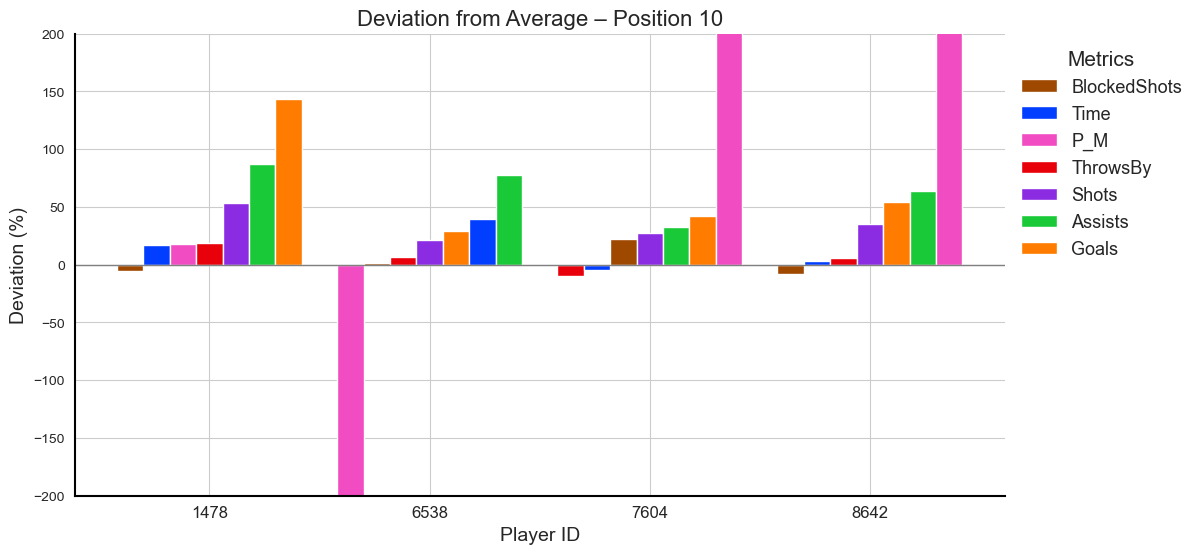

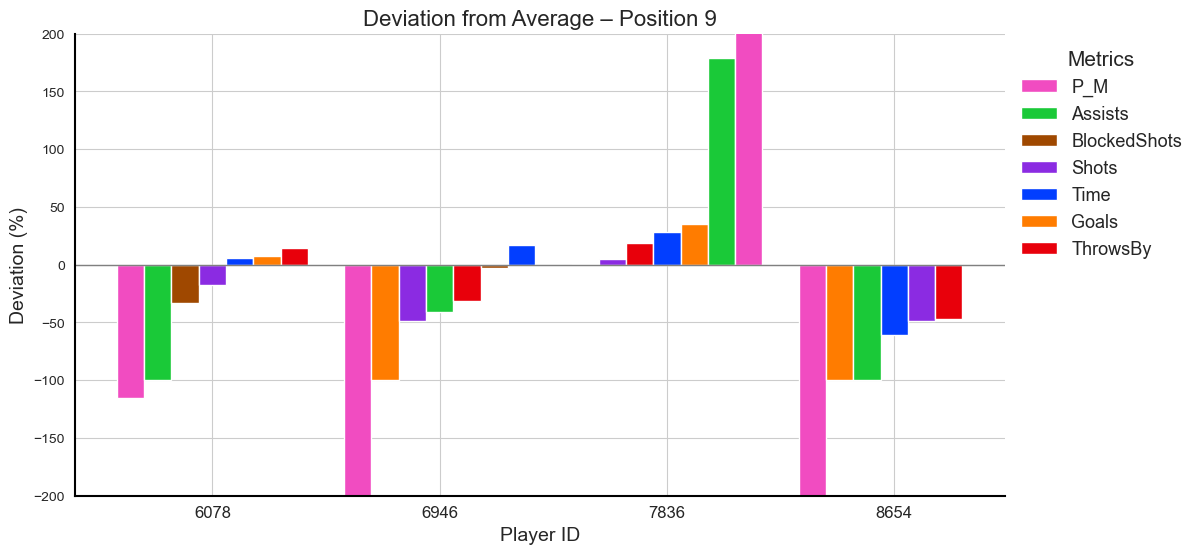

In [8]:
# Построение графиков для игроков с amplua 10
plot_player_deviation(mean_stats_pl, amplua=10, player_ids=[1478, 7604, 6538, 8642], bar_width=0.12, figsize=(12, 6))
# Построение графиков для игроков с amplua 9
plot_player_deviation(mean_stats_pl, amplua=9, player_ids=[7836, 6078, 6946, 8654])